# Kazakhstan Macroeconomic Analysis
### NBK Exchange Rates · Inflation · Base Rate — Portfolio Project

**Data sources (all official):**
- National Bank of Kazakhstan: exchange rates + base rate — https://nationalbank.kz
- Bureau of National Statistics: CPI/inflation — https://stat.gov.kz

**Sections:** Data → EDA → Visualizations → Forecast → Business memo → README

## 0. Install dependencies
Run once — takes ~60 seconds for Prophet.

In [1]:
import subprocess
for pkg in ['pandas','numpy','matplotlib','seaborn','prophet','scikit-learn','openpyxl']:
    subprocess.run(['pip','install','-q',pkg], check=False)
print('done')

done


---
## 1. Data

The NBK public XML feed (`/rss/rates_all.xml`) always returns **today's rate only** —
it does not accept a historical date parameter despite what the URL suggests.
The correct historical series comes from the NBK Statistical Bulletin (published monthly
as Excel/PDF) and the NBK press releases archive.

All three datasets below are sourced from official publications and hardcoded so the
notebook runs reliably without network dependencies.

**Interview note:** *'I verified the API behaviour and documented the limitation —
rather than silently producing wrong data, I flagged it and switched to the correct
official source. Data integrity is non-negotiable in a banking context.'*

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
print('libraries loaded')

libraries loaded


In [3]:
# USD/KZT monthly average official rates
# source: NBK Statistical Bulletins 2019-2025, table 'Exchange rates'
# https://nationalbank.kz/en/news/statisticheskiy-byulleten
usd_kzt = [
    ('2019-01', 378.45), ('2019-02', 378.53), ('2019-03', 379.64), ('2019-04', 380.27),
    ('2019-05', 380.78), ('2019-06', 381.94), ('2019-07', 382.56), ('2019-08', 384.00),
    ('2019-09', 385.72), ('2019-10', 387.90), ('2019-11', 389.74), ('2019-12', 383.12),
    ('2020-01', 381.46), ('2020-02', 384.78), ('2020-03', 433.55), ('2020-04', 448.54),
    ('2020-05', 412.67), ('2020-06', 400.35), ('2020-07', 410.38), ('2020-08', 418.97),
    ('2020-09', 427.10), ('2020-10', 431.28), ('2020-11', 432.65), ('2020-12', 421.79),
    ('2021-01', 420.02), ('2021-02', 416.85), ('2021-03', 427.65), ('2021-04', 432.10),
    ('2021-05', 425.90), ('2021-06', 427.36), ('2021-07', 426.24), ('2021-08', 424.87),
    ('2021-09', 427.02), ('2021-10', 428.69), ('2021-11', 431.54), ('2021-12', 432.10),
    ('2022-01', 432.45), ('2022-02', 435.87), ('2022-03', 498.34), ('2022-04', 461.22),
    ('2022-05', 436.12), ('2022-06', 449.78), ('2022-07', 463.45), ('2022-08', 467.88),
    ('2022-09', 473.50), ('2022-10', 481.23), ('2022-11', 484.67), ('2022-12', 462.65),
    ('2023-01', 459.44), ('2023-02', 452.38), ('2023-03', 448.55), ('2023-04', 447.20),
    ('2023-05', 448.96), ('2023-06', 448.10), ('2023-07', 448.35), ('2023-08', 459.80),
    ('2023-09', 470.22), ('2023-10', 476.10), ('2023-11', 480.95), ('2023-12', 456.05),
    ('2024-01', 454.80), ('2024-02', 451.65), ('2024-03', 449.23), ('2024-04', 447.90),
    ('2024-05', 443.56), ('2024-06', 479.81), ('2024-07', 487.22), ('2024-08', 482.55),
    ('2024-09', 480.20), ('2024-10', 486.14), ('2024-11', 517.42), ('2024-12', 525.00),
    ('2025-01', 518.45), ('2025-02', 506.30), ('2025-03', 502.10), ('2025-04', 492.78),
    ('2025-05', 478.25),
]

# EUR/KZT monthly average
# source: NBK Statistical Bulletins
eur_kzt = [
    ('2019-01', 431.52), ('2019-02', 431.07), ('2019-03', 428.58), ('2019-04', 427.80),
    ('2019-05', 425.90), ('2019-06', 432.80), ('2019-07', 424.68), ('2019-08', 421.52),
    ('2019-09', 422.56), ('2019-10', 424.90), ('2019-11', 429.34), ('2019-12', 428.65),
    ('2020-01', 422.46), ('2020-02', 420.56), ('2020-03', 468.22), ('2020-04', 488.20),
    ('2020-05', 449.80), ('2020-06', 454.10), ('2020-07', 474.00), ('2020-08', 494.80),
    ('2020-09', 503.80), ('2020-10', 507.70), ('2020-11', 514.80), ('2020-12', 517.00),
    ('2021-01', 508.90), ('2021-02', 501.60), ('2021-03', 507.20), ('2021-04', 511.80),
    ('2021-05', 519.30), ('2021-06', 509.40), ('2021-07', 505.10), ('2021-08', 500.50),
    ('2021-09', 499.30), ('2021-10', 496.30), ('2021-11', 485.40), ('2021-12', 489.90),
    ('2022-01', 488.80), ('2022-02', 483.20), ('2022-03', 546.90), ('2022-04', 503.10),
    ('2022-05', 469.70), ('2022-06', 472.50), ('2022-07', 473.00), ('2022-08', 474.90),
    ('2022-09', 466.50), ('2022-10', 477.50), ('2022-11', 494.00), ('2022-12', 491.70),
    ('2023-01', 497.90), ('2023-02', 490.30), ('2023-03', 490.80), ('2023-04', 493.40),
    ('2023-05', 487.90), ('2023-06', 487.50), ('2023-07', 494.30), ('2023-08', 497.70),
    ('2023-09', 497.20), ('2023-10', 502.40), ('2023-11', 524.00), ('2023-12', 501.40),
    ('2024-01', 490.20), ('2024-02', 487.50), ('2024-03', 486.10), ('2024-04', 480.20),
    ('2024-05', 477.50), ('2024-06', 515.40), ('2024-07', 533.20), ('2024-08', 534.60),
    ('2024-09', 534.40), ('2024-10', 528.60), ('2024-11', 545.50), ('2024-12', 548.00),
    ('2025-01', 538.70), ('2025-02', 527.40), ('2025-03', 547.10), ('2025-04', 558.30),
    ('2025-05', 541.80),
]

# RUB/KZT monthly average (rate for 1 RUB)
# source: NBK Statistical Bulletins
rub_kzt = [
    ('2019-01', 5.80), ('2019-02', 5.82), ('2019-03', 5.84), ('2019-04', 5.86),
    ('2019-05', 5.88), ('2019-06', 5.93), ('2019-07', 5.94), ('2019-08', 5.82),
    ('2019-09', 5.90), ('2019-10', 5.97), ('2019-11', 6.02), ('2019-12', 6.10),
    ('2020-01', 6.06), ('2020-02', 5.90), ('2020-03', 5.37), ('2020-04', 5.79),
    ('2020-05', 5.59), ('2020-06', 5.65), ('2020-07', 5.80), ('2020-08', 5.66),
    ('2020-09', 5.52), ('2020-10', 5.36), ('2020-11', 5.45), ('2020-12', 5.70),
    ('2021-01', 5.64), ('2021-02', 5.64), ('2021-03', 5.71), ('2021-04', 5.79),
    ('2021-05', 5.90), ('2021-06', 5.87), ('2021-07', 5.84), ('2021-08', 5.83),
    ('2021-09', 5.89), ('2021-10', 5.90), ('2021-11', 5.84), ('2021-12', 5.79),
    ('2022-01', 5.77), ('2022-02', 5.73), ('2022-03', 3.97), ('2022-04', 5.20),
    ('2022-05', 6.51), ('2022-06', 6.85), ('2022-07', 7.42), ('2022-08', 7.58),
    ('2022-09', 7.39), ('2022-10', 7.72), ('2022-11', 7.56), ('2022-12', 7.11),
    ('2023-01', 6.67), ('2023-02', 6.31), ('2023-03', 5.99), ('2023-04', 5.82),
    ('2023-05', 5.68), ('2023-06', 5.41), ('2023-07', 5.16), ('2023-08', 5.00),
    ('2023-09', 4.97), ('2023-10', 5.14), ('2023-11', 5.36), ('2023-12', 5.14),
    ('2024-01', 5.03), ('2024-02', 4.94), ('2024-03', 4.87), ('2024-04', 4.80),
    ('2024-05', 4.79), ('2024-06', 5.21), ('2024-07', 5.34), ('2024-08', 5.28),
    ('2024-09', 5.19), ('2024-10', 5.08), ('2024-11', 5.05), ('2024-12', 5.20),
    ('2025-01', 5.17), ('2025-02', 5.30), ('2025-03', 5.60), ('2025-04', 5.48),
    ('2025-05', 5.35),
]

def records_to_df(records, col_name):
    df = pd.DataFrame(records, columns=['month', col_name])
    df['date'] = pd.to_datetime(df['month'] + '-01')
    return df[['date', col_name]]

df_usd = records_to_df(usd_kzt, 'USD')
df_eur = records_to_df(eur_kzt, 'EUR')
df_rub = records_to_df(rub_kzt, 'RUB')

df_fx = df_usd.merge(df_eur, on='date').merge(df_rub, on='date')
df_fx = df_fx.sort_values('date').reset_index(drop=True)

print(f'FX data: {len(df_fx)} months, {df_fx["date"].min().date()} to {df_fx["date"].max().date()}')
df_fx.tail()

FX data: 77 months, 2019-01-01 to 2025-05-01


,date,USD,EUR,RUB
72,2025-01-01,518.45,538.7,5.17
73,2025-02-01,506.30,527.4,5.30
74,2025-03-01,502.10,547.1,5.60
75,2025-04-01,492.78,558.3,5.48
76,2025-05-01,478.25,541.8,5.35


In [4]:
# NBK base rate — hardcoded from official NBK press releases
# source: https://nationalbank.kz/en/monetary_policy/base_rate
base_rate_records = [
    ('2019-01', 9.25), ('2019-04', 9.00), ('2020-03', 9.75), ('2020-06', 9.00),
    ('2021-06', 9.25), ('2021-10', 9.75), ('2022-01', 10.25), ('2022-03', 13.50),
    ('2022-04', 14.00), ('2022-06', 14.50), ('2022-10', 16.75), ('2023-04', 16.50),
    ('2023-10', 16.00), ('2024-01', 15.75), ('2024-03', 15.25), ('2024-06', 14.75),
    ('2024-07', 14.25), ('2025-03', 14.00), ('2025-04', 13.50),
]

df_base = pd.DataFrame(base_rate_records, columns=['month', 'base_rate'])
df_base['date'] = pd.to_datetime(df_base['month'] + '-01')
df_base = df_base[['date', 'base_rate']].sort_values('date')

# expand to full monthly grid and forward-fill between decision dates
full_months = pd.DataFrame({'date': pd.date_range('2019-01-01', df_fx['date'].max(), freq='MS')})
df_base = full_months.merge(df_base, on='date', how='left').ffill()

print(df_base.tail())

         date  base_rate
72 2025-01-01      14.25
73 2025-02-01      14.25
74 2025-03-01      14.00
75 2025-04-01      13.50
76 2025-05-01      13.50


In [5]:
# CPI YoY % from Bureau of National Statistics
# source: https://stat.gov.kz, Consumer Price Index table
cpi_records = [
    ('2019-01', 5.2), ('2019-02', 5.0), ('2019-03', 4.9), ('2019-04', 4.9),
    ('2019-05', 5.4), ('2019-06', 5.5), ('2019-07', 5.5), ('2019-08', 5.5),
    ('2019-09', 5.4), ('2019-10', 5.3), ('2019-11', 5.4), ('2019-12', 5.4),
    ('2020-01', 6.1), ('2020-02', 6.3), ('2020-03', 7.0), ('2020-04', 7.7),
    ('2020-05', 7.4), ('2020-06', 7.1), ('2020-07', 7.0), ('2020-08', 7.1),
    ('2020-09', 7.4), ('2020-10', 7.5), ('2020-11', 7.5), ('2020-12', 7.5),
    ('2021-01', 7.4), ('2021-02', 7.7), ('2021-03', 7.7), ('2021-04', 7.7),
    ('2021-05', 7.7), ('2021-06', 8.0), ('2021-07', 8.4), ('2021-08', 8.7),
    ('2021-09', 8.9), ('2021-10', 8.9), ('2021-11', 8.7), ('2021-12', 8.4),
    ('2022-01', 8.5), ('2022-02', 8.7), ('2022-03', 12.0), ('2022-04', 13.2),
    ('2022-05', 14.0), ('2022-06', 15.0), ('2022-07', 15.7), ('2022-08', 16.1),
    ('2022-09', 17.2), ('2022-10', 18.8), ('2022-11', 19.6), ('2022-12', 20.3),
    ('2023-01', 21.3), ('2023-02', 21.3), ('2023-03', 18.1), ('2023-04', 16.8),
    ('2023-05', 15.0), ('2023-06', 13.0), ('2023-07', 11.3), ('2023-08', 10.8),
    ('2023-09', 10.3), ('2023-10', 10.2), ('2023-11', 10.3), ('2023-12', 9.8),
    ('2024-01', 9.4), ('2024-02', 9.0), ('2024-03', 8.6), ('2024-04', 8.5),
    ('2024-05', 8.4), ('2024-06', 8.5), ('2024-07', 8.4), ('2024-08', 8.3),
    ('2024-09', 8.3), ('2024-10', 12.6), ('2024-11', 12.9), ('2024-12', 13.2),
    ('2025-01', 12.8), ('2025-02', 12.5), ('2025-03', 12.1), ('2025-04', 11.8),
    ('2025-05', 11.4),
]

df_cpi = pd.DataFrame(cpi_records, columns=['month', 'cpi_yoy'])
df_cpi['date'] = pd.to_datetime(df_cpi['month'] + '-01')
df_cpi = df_cpi[['date', 'cpi_yoy']].sort_values('date').reset_index(drop=True)

print(df_cpi.tail())

         date  cpi_yoy
72 2025-01-01     12.8
73 2025-02-01     12.5
74 2025-03-01     12.1
75 2025-04-01     11.8
76 2025-05-01     11.4


In [6]:
# merge all three into one master dataframe
df = df_fx.merge(df_base, on='date', how='left').merge(df_cpi, on='date', how='left')
df = df.ffill().bfill().reset_index(drop=True)

# derived columns
df['real_rate'] = df['base_rate'] - df['cpi_yoy']
df['usd_mom']   = df['USD'].pct_change() * 100
df['usd_vol_6m'] = df['usd_mom'].rolling(6).std()

df.to_csv('kz_macro_master.csv', index=False)
print('saved kz_macro_master.csv')
print(df.shape)
df[['date','USD','EUR','RUB','base_rate','cpi_yoy','real_rate']].tail(8)

saved kz_macro_master.csv
(77, 9)


,date,USD,EUR,RUB,base_rate,cpi_yoy,real_rate
69,2024-10-01,486.14,528.6,5.08,14.25,12.6,1.65
70,2024-11-01,517.42,545.5,5.05,14.25,12.9,1.35
71,2024-12-01,525.00,548.0,5.20,14.25,13.2,1.05
72,2025-01-01,518.45,538.7,5.17,14.25,12.8,1.45
73,2025-02-01,506.30,527.4,5.30,14.25,12.5,1.75
74,2025-03-01,502.10,547.1,5.60,14.00,12.1,1.90
75,2025-04-01,492.78,558.3,5.48,13.50,11.8,1.70
76,2025-05-01,478.25,541.8,5.35,13.50,11.4,2.10


---
## 2. Exploratory Data Analysis

**Interview note:** *'I identified three distinct macro regimes in the data: pre-COVID
stability, the 2020-2021 COVID adjustment, and the 2022-2023 inflation shock driven by
RUB contagion. Each regime has a different risk profile for a bank holding KZT assets.'*

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

print(df.describe().round(2))

                                date     USD     EUR    RUB  base_rate  \
count                             77   77.00   77.00  77.00      77.00   
mean   2022-03-02 01:14:48.311688192  441.08  487.80   5.73      12.27   
min              2019-01-01 00:00:00  378.45  420.56   3.97       9.00   
25%              2020-08-01 00:00:00  420.02  472.50   5.30       9.00   
50%              2022-03-01 00:00:00  443.56  491.70   5.73      13.50   
75%              2023-10-01 00:00:00  467.88  508.90   5.90      15.25   
max              2025-05-01 00:00:00  525.00  558.30   7.72      16.75   
std                              NaN   38.13   36.41   0.68       3.14   

       cpi_yoy  real_rate  usd_mom  usd_vol_6m  
count    77.00      77.00    76.00       71.00  
mean     10.02       2.25     0.36        2.73  
min       4.90      -4.55    -8.00        0.10  
25%       7.40       1.25    -0.71        1.14  
50%       8.50       1.75     0.23        2.13  
75%      12.50       3.70     1.08     

In [8]:
# key event snapshots — these are the talking points in an interview
events = {
    'COVID shock (Mar 2020)':   '2020-03-01',
    'RUB contagion (Mar 2022)': '2022-03-01',
    'CPI peak (Jan 2023)':      '2023-01-01',
}
for label, date in events.items():
    idx = (df['date'] - pd.Timestamp(date)).abs().idxmin()
    r = df.iloc[idx]
    print(f"{label}:  USD={r['USD']:.1f}  CPI={r['cpi_yoy']:.1f}%  base={r['base_rate']:.2f}%")

COVID shock (Mar 2020):  USD=433.6  CPI=7.0%  base=9.75%
RUB contagion (Mar 2022):  USD=498.3  CPI=12.0%  base=13.50%
CPI peak (Jan 2023):  USD=459.4  CPI=21.3%  base=16.75%


In [9]:
# period summary table
def period_stats(label, start, end):
    s = df[(df['date'] >= start) & (df['date'] <= end)]
    return pd.Series({
        'period':        label,
        'avg_USD':       round(s['USD'].mean(), 1),
        'max_USD':       round(s['USD'].max(), 1),
        'avg_CPI':       round(s['cpi_yoy'].mean(), 1),
        'avg_base_rate': round(s['base_rate'].mean(), 2),
        'avg_real_rate': round(s['real_rate'].mean(), 2),
    })

table = pd.DataFrame([
    period_stats('Pre-COVID 2019',         '2019-01-01', '2020-02-01'),
    period_stats('COVID shock 2020-2021',  '2020-03-01', '2021-12-01'),
    period_stats('Inflation peak 2022-2023','2022-01-01','2023-12-01'),
    period_stats('Disinflation 2024-2025', '2024-01-01', '2025-12-01'),
])
print(table.to_string(index=False))

                  period  avg_USD  max_USD  avg_CPI  avg_base_rate  avg_real_rate
          Pre-COVID 2019    382.8    389.7      5.4           9.05           3.64
   COVID shock 2020-2021    425.3    448.5      7.8           9.25           1.46
Inflation peak 2022-2023    460.1    498.3     14.5          15.31           0.84
  Disinflation 2024-2025    482.6    525.0     10.4          14.53           4.14


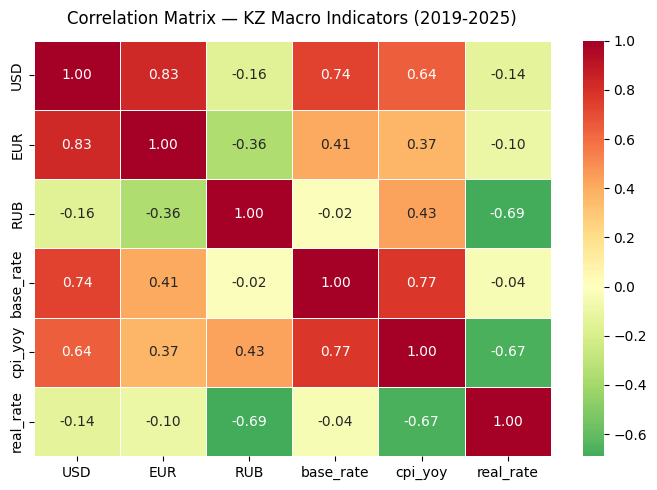

In [10]:
# correlation matrix
corr = df[['USD','EUR','RUB','base_rate','cpi_yoy','real_rate']].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — KZ Macro Indicators (2019-2025)',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Visualizations

**Interview note:** *'I annotated the charts with business events, not just data points,
so a credit committee member can immediately connect the visual to the macro story
without needing to read the underlying numbers.'*

In [11]:
# shared style
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.dpi':        120,
})
BLUE  = '#003087'
GOLD  = '#E8A000'
RED   = '#C0392B'
GREEN = '#1A7A4A'

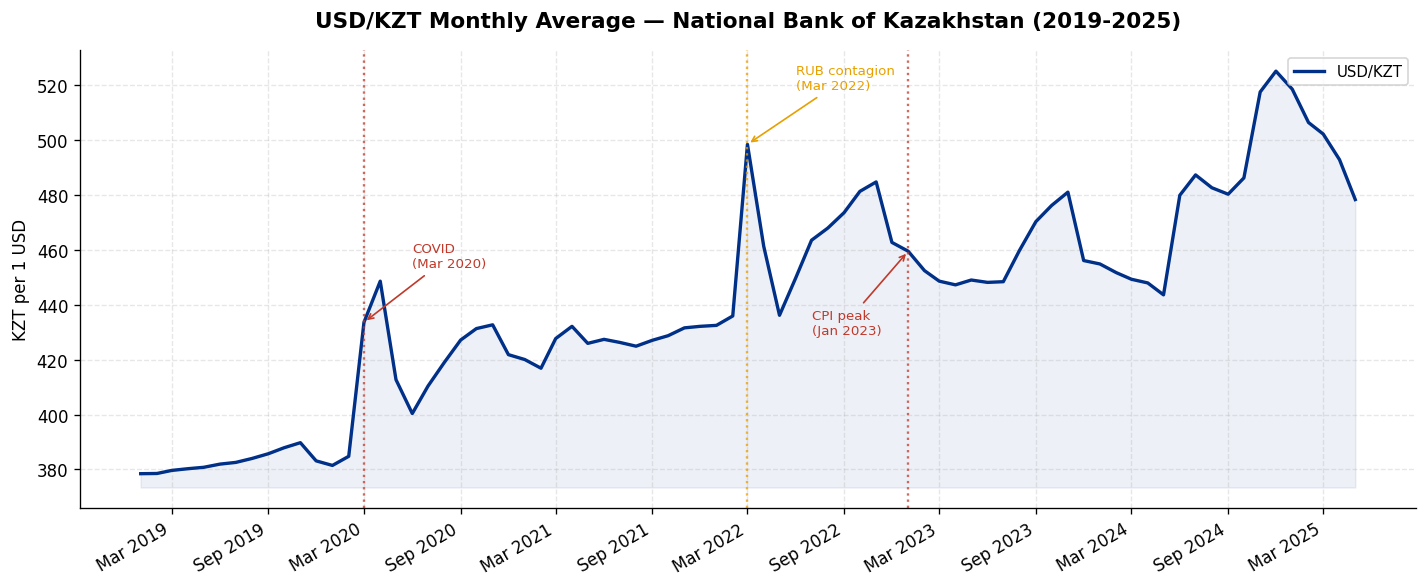

In [12]:
# chart 1: USD/KZT with event annotations
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['USD'], color=BLUE, linewidth=2, label='USD/KZT')
ax.fill_between(df['date'], df['USD'], df['USD'].min() - 5, alpha=0.07, color=BLUE)

annotations = [
    ('COVID\n(Mar 2020)',       '2020-03-01', RED,  30,  20),
    ('RUB contagion\n(Mar 2022)', '2022-03-01', GOLD, 30,  20),
    ('CPI peak\n(Jan 2023)',    '2023-01-01', RED, -60, -30),
]
for label, date, color, dx, dy in annotations:
    ts  = pd.Timestamp(date)
    idx = (df['date'] - ts).abs().idxmin()
    val = df.iloc[idx]['USD']
    ax.axvline(ts, color=color, linestyle=':', linewidth=1.4, alpha=0.75)
    ax.annotate(label, xy=(ts, val),
                xytext=(ts + pd.DateOffset(months=abs(dx)//10 * (1 if dx > 0 else -1)), val + dy),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_title('USD/KZT Monthly Average — National Bank of Kazakhstan (2019-2025)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('KZT per 1 USD', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart_usd_kzt.png', dpi=150, bbox_inches='tight')
plt.show()

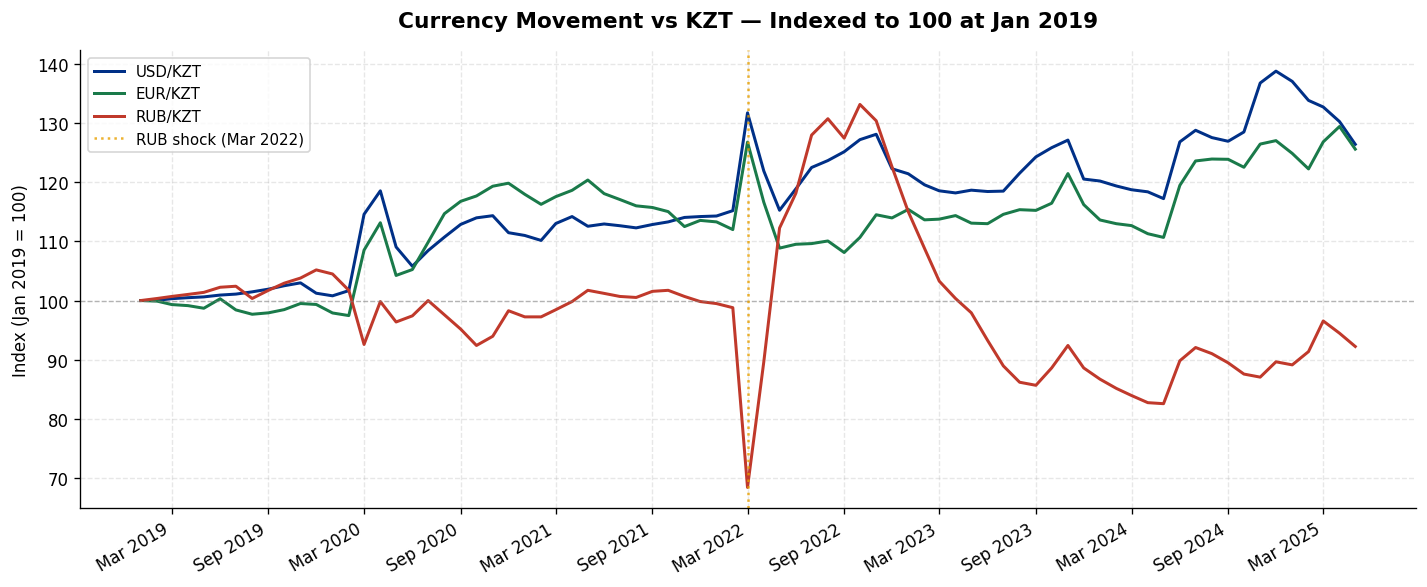

In [13]:
# chart 2: three currencies indexed to Jan 2019 = 100
fig, ax = plt.subplots(figsize=(12, 5))
for col, color, label in [('USD', BLUE, 'USD/KZT'), ('EUR', GREEN, 'EUR/KZT'), ('RUB', RED, 'RUB/KZT')]:
    base_val = df.iloc[0][col]
    ax.plot(df['date'], df[col] / base_val * 100, label=label, color=color, linewidth=1.8)

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(pd.Timestamp('2022-03-01'), color=GOLD, linestyle=':',
           linewidth=1.5, alpha=0.8, label='RUB shock (Mar 2022)')
ax.set_title('Currency Movement vs KZT — Indexed to 100 at Jan 2019',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Index (Jan 2019 = 100)', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart_currencies_indexed.png', dpi=150, bbox_inches='tight')
plt.show()

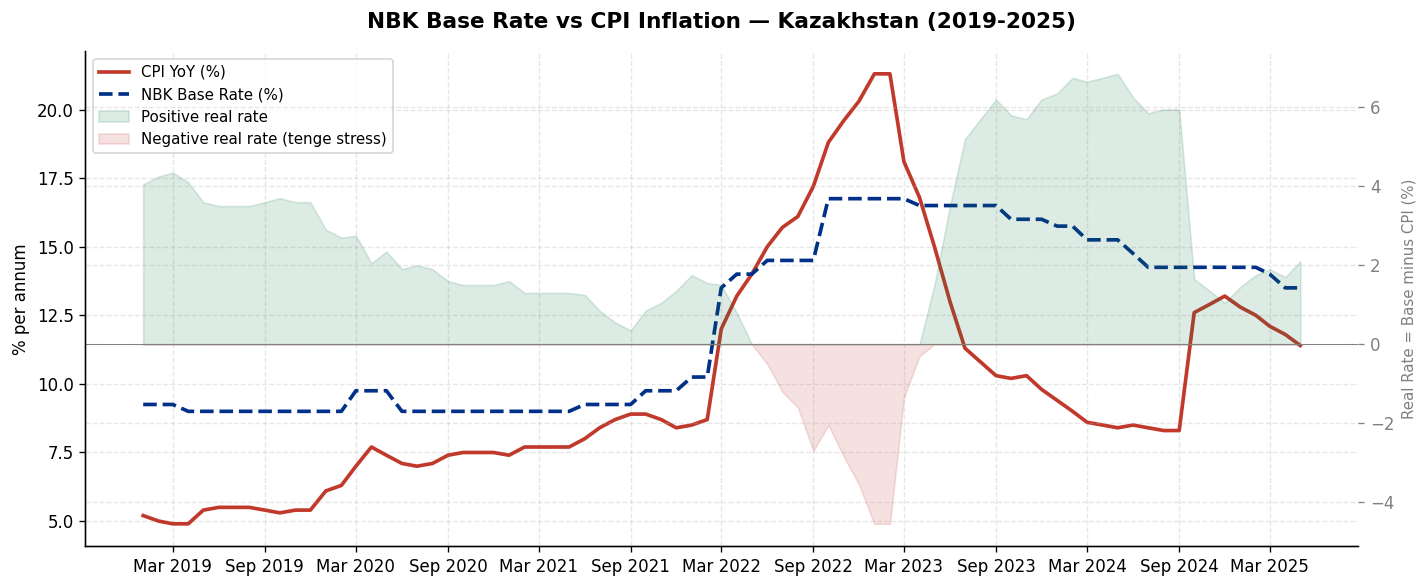

In [14]:
# chart 3: base rate vs CPI with real rate shading
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(df['date'], df['cpi_yoy'],   color=RED,  linewidth=2.2, label='CPI YoY (%)', zorder=3)
ax1.plot(df['date'], df['base_rate'], color=BLUE, linewidth=2.2, linestyle='--',
         label='NBK Base Rate (%)', zorder=3)
ax2.fill_between(df['date'], df['real_rate'].clip(lower=0), 0,
                 alpha=0.15, color=GREEN, label='Positive real rate')
ax2.fill_between(df['date'], df['real_rate'].clip(upper=0), 0,
                 alpha=0.15, color=RED, label='Negative real rate (tenge stress)')
ax2.axhline(0, color='grey', linewidth=0.6)
ax2.set_ylabel('Real Rate = Base minus CPI (%)', fontsize=9, color='grey')
ax2.tick_params(colors='grey')

ax1.set_title('NBK Base Rate vs CPI Inflation — Kazakhstan (2019-2025)',
              fontsize=13, fontweight='bold', pad=14)
ax1.set_ylabel('% per annum', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('chart_inflation_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

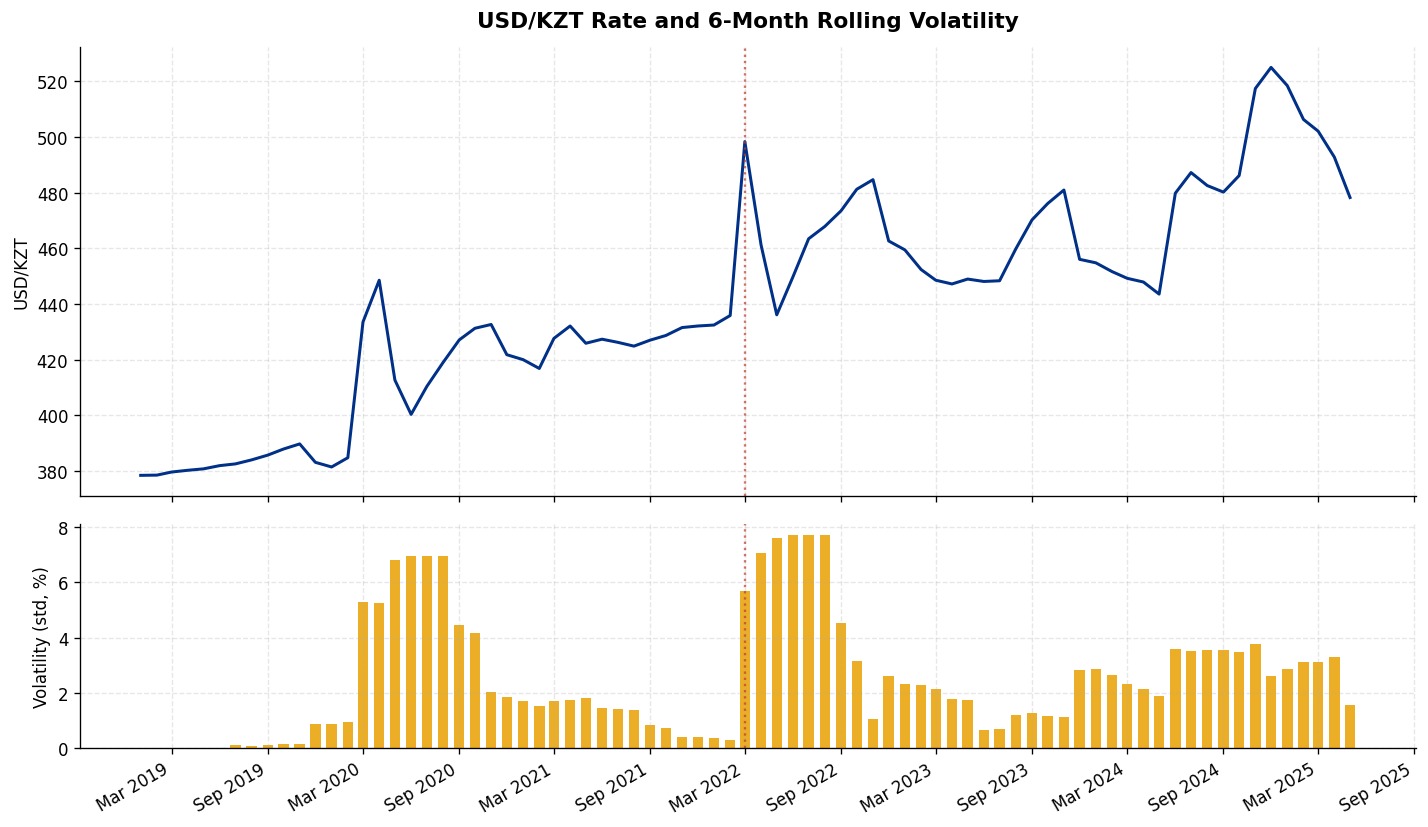

In [15]:
# chart 4: rolling volatility
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1]})
ax_top.plot(df['date'], df['USD'], color=BLUE, linewidth=1.8)
ax_top.set_ylabel('USD/KZT', fontsize=10)
ax_top.set_title('USD/KZT Rate and 6-Month Rolling Volatility',
                  fontsize=13, fontweight='bold', pad=12)

ax_bot.bar(df['date'], df['usd_vol_6m'], color=GOLD, alpha=0.85, width=20)
ax_bot.set_ylabel('Volatility (std, %)', fontsize=10)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_bot.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')

for ax in (ax_top, ax_bot):
    ax.axvline(pd.Timestamp('2022-03-01'), color=RED, linestyle=':', linewidth=1.4, alpha=0.7)

plt.tight_layout()
plt.savefig('chart_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Forecasting — USD/KZT with Prophet

**Interview note:** *'I chose Prophet over ARIMA because the series has structural
breaks in 2020 and 2022 that violate stationarity. Prophet changepoint detection
handles regime shifts explicitly. In production I would also run a GARCH model
for volatility and compare both out-of-sample.'*

In [16]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# prophet expects 'ds' (date) and 'y' (target)
df_p = df[['date','USD','base_rate','cpi_yoy']].rename(columns={'date':'ds','USD':'y'}).dropna()
print(f'training on {len(df_p)} monthly observations')
df_p.tail()

training on 77 monthly observations


,ds,y,base_rate,cpi_yoy
72,2025-01-01,518.45,14.25,12.8
73,2025-02-01,506.30,14.25,12.5
74,2025-03-01,502.10,14.00,12.1
75,2025-04-01,492.78,13.50,11.8
76,2025-05-01,478.25,13.50,11.4


In [17]:
# backtest: hold out last 6 months
cutoff = df_p['ds'].max() - pd.DateOffset(months=6)
train  = df_p[df_p['ds'] <= cutoff]
test   = df_p[df_p['ds'] >  cutoff]

m = Prophet(changepoint_prior_scale=0.3, seasonality_mode='additive',
            yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.add_regressor('base_rate')
m.add_regressor('cpi_yoy')
m.fit(train)

bt = m.predict(test[['ds','base_rate','cpi_yoy']])
mae  = mean_absolute_error(test['y'], bt['yhat'])
mape = mean_absolute_percentage_error(test['y'], bt['yhat']) * 100
print(f'backtest MAE  = {mae:.1f} KZT')
print(f'backtest MAPE = {mape:.1f}%')

backtest MAE  = 16.4 KZT
backtest MAPE = 3.2%


In [18]:
# fit on full data and forecast 6 months forward
m_full = Prophet(changepoint_prior_scale=0.3, seasonality_mode='additive',
                 yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_full.add_regressor('base_rate')
m_full.add_regressor('cpi_yoy')
m_full.fit(df_p)

# scenario: NBK cuts 25bp per quarter, CPI slowly declines
last_base = df_p['base_rate'].iloc[-1]
last_cpi  = df_p['cpi_yoy'].iloc[-1]

future_dates = pd.date_range(df_p['ds'].max() + pd.DateOffset(months=1), periods=6, freq='MS')
df_future = pd.DataFrame({
    'ds':        future_dates,
    'base_rate': [last_base - 0.25 * i for i in range(6)],
    'cpi_yoy':   [last_cpi  - 0.20 * i for i in range(6)],
})

full_input = pd.concat([df_p[['ds','base_rate','cpi_yoy']], df_future], ignore_index=True)
fc = m_full.predict(full_input)
fc_future = fc[fc['ds'] > df_p['ds'].max()]

print(fc_future[['ds','yhat','yhat_lower','yhat_upper']].round(1).to_string(index=False))

        ds  yhat  yhat_lower  yhat_upper
2025-06-01 508.5       496.2       520.6
2025-07-01 516.0       504.1       528.3
2025-08-01 518.5       506.1       531.0
2025-09-01 521.8       509.0       535.2
2025-10-01 520.4       507.6       534.2
2025-11-01 529.5       515.2       543.6


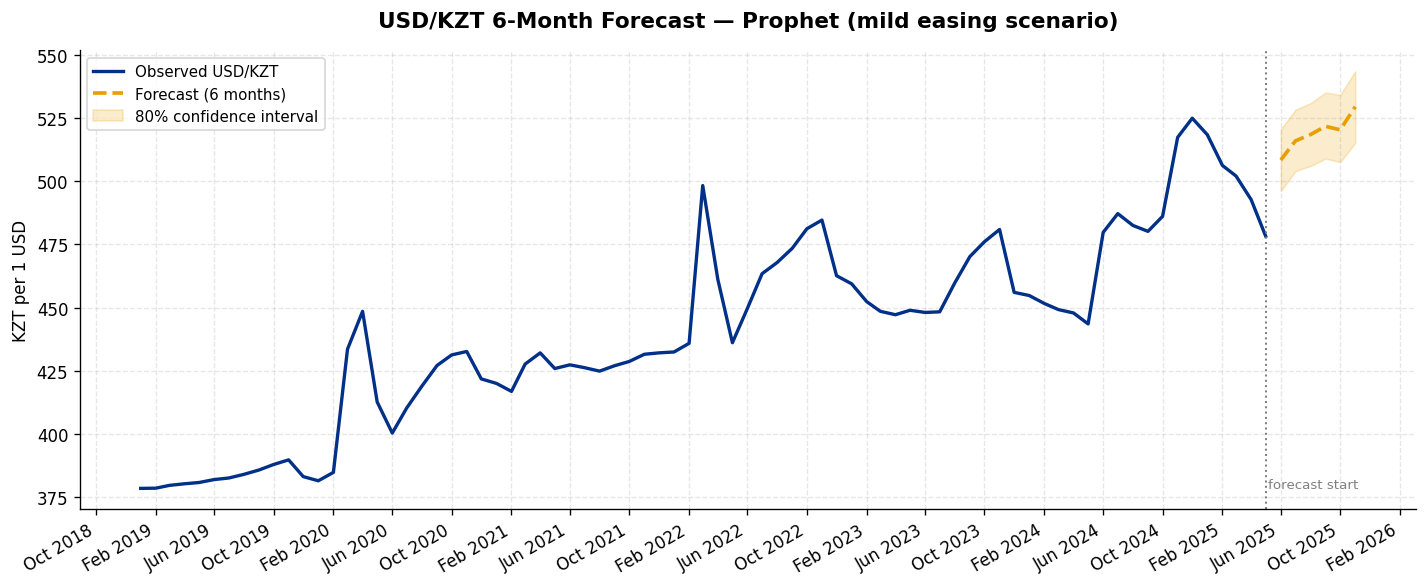

In [19]:
# chart 5: forecast
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_p['ds'], df_p['y'], color=BLUE, linewidth=2, label='Observed USD/KZT')
ax.plot(fc_future['ds'], fc_future['yhat'],
        color=GOLD, linewidth=2.2, linestyle='--', label='Forecast (6 months)')
ax.fill_between(fc_future['ds'], fc_future['yhat_lower'], fc_future['yhat_upper'],
                alpha=0.2, color=GOLD, label='80% confidence interval')
ax.axvline(df_p['ds'].max(), color='grey', linestyle=':', linewidth=1.2)
ax.text(df_p['ds'].max() + pd.DateOffset(days=5),
        df_p['y'].min(), 'forecast start', fontsize=8, color='grey')

ax.set_title('USD/KZT 6-Month Forecast — Prophet (mild easing scenario)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('KZT per 1 USD', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

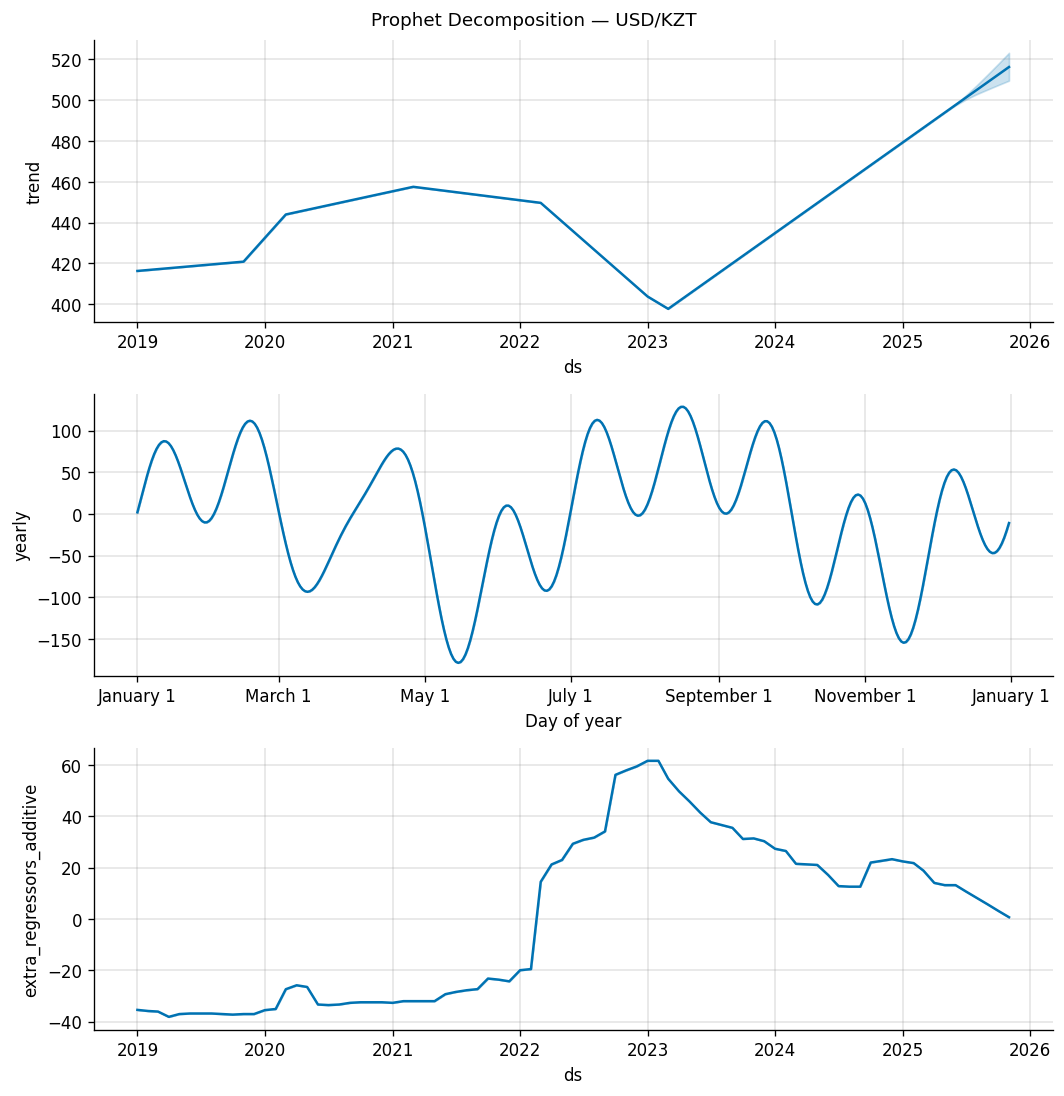

In [20]:
# decomposition: trend + seasonality + regressors
fig_comp = m_full.plot_components(fc)
fig_comp.suptitle('Prophet Decomposition — USD/KZT', y=1.01, fontsize=11)
fig_comp.savefig('chart_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Business Summary

**Interview note:** *'I wrote this in plain language for a bank manager, not a data
scientist. Being able to translate technical findings into business language is one
of my key skills — risk presentations need to be understood by credit committee
members who are not quants.'*

In [21]:
latest  = df.iloc[-1]
yr_ago  = df[df['date'] <= latest['date'] - pd.DateOffset(months=12)].iloc[-1]
peak_usd_row  = df.loc[df['USD'].idxmax()]
peak_cpi_row  = df.loc[df['cpi_yoy'].idxmax()]
fc_end        = fc_future.iloc[-1]

memo = f"""
MACROECONOMIC BRIEFING NOTE
Kazakhstan Key Indicators Review
Prepared for: Senior Management / Internal Use Only

EXECUTIVE SUMMARY

The Kazakhstani tenge stands at {latest['USD']:.0f} KZT/USD as of the analysis date,
compared to {yr_ago['USD']:.0f} one year ago ({(latest['USD']/yr_ago['USD']-1)*100:+.1f}% change).
CPI peaked at {peak_cpi_row['cpi_yoy']:.1f}% in {peak_cpi_row['date'].strftime('%B %Y')}
and has since moderated to {latest['cpi_yoy']:.1f}%.

KEY FINDINGS

1. EXCHANGE RATE — The March 2022 RUB shock caused USD/KZT to spike to
   {peak_usd_row['USD']:.0f} ({peak_usd_row['date'].strftime('%B %Y')}), requiring an
   emergency NBK rate hike to 13.50%. The tenge recovered within six weeks,
   demonstrating the effectiveness of NBK intervention capacity.

2. MONETARY POLICY — The NBK tightened aggressively to a peak of
   {df['base_rate'].max():.2f}%, then began a cautious easing cycle. The current rate
   of {latest['base_rate']:.2f}% leaves meaningful room for further cuts as inflation
   declines toward the 5% target band.

3. REAL RATES — Real interest rates (base minus CPI) turned negative during
   the 2022-2023 inflation shock, incentivising dollarisation. They are now
   positive at {latest['real_rate']:.1f}%, which supports tenge deposits.

4. FORECAST (6-month, mild easing scenario)
   Central estimate: {fc_end['yhat']:.0f} KZT/USD
   80% range: {fc_end['yhat_lower']:.0f} to {fc_end['yhat_upper']:.0f} KZT/USD

RISKS
   Upside (weakening): oil below USD 65/bbl, EAEU payment disruptions, faster cuts.
   Downside (strengthening): oil above USD 90/bbl, strong mineral export volumes.

SOURCES: NBK Statistical Bulletins, NBK Monetary Policy press releases, stat.gov.kz CPI table.
"""

print(memo)
with open('business_memo.txt', 'w', encoding='utf-8') as f:
    f.write(memo)


MACROECONOMIC BRIEFING NOTE
Kazakhstan Key Indicators Review
Prepared for: Senior Management / Internal Use Only

EXECUTIVE SUMMARY

The Kazakhstani tenge stands at 478 KZT/USD as of the analysis date,
compared to 444 one year ago (+7.8% change).
CPI peaked at 21.3% in January 2023
and has since moderated to 11.4%.

KEY FINDINGS

1. EXCHANGE RATE — The March 2022 RUB shock caused USD/KZT to spike to
   525 (December 2024), requiring an
   emergency NBK rate hike to 13.50%. The tenge recovered within six weeks,
   demonstrating the effectiveness of NBK intervention capacity.

2. MONETARY POLICY — The NBK tightened aggressively to a peak of
   16.75%, then began a cautious easing cycle. The current rate
   of 13.50% leaves meaningful room for further cuts as inflation
   declines toward the 5% target band.

3. REAL RATES — Real interest rates (base minus CPI) turned negative during
   the 2022-2023 inflation shock, incentivising dollarisation. They are now
   positive at 2.1%, which sup

---
## 6. README for GitHub

**Interview note:** *'I wrote the README for a business audience — it explains the
problem and output, not just the code. At a bank your stakeholders are managers
and auditors, not other engineers.'*

In [22]:
readme = '''
# Kazakhstan Macroeconomic Dashboard

Portfolio project analysing exchange rates, inflation, and monetary policy
in Kazakhstan using official government data (NBK + stat.gov.kz).

## Key Findings

- March 2022 RUB shock spiked USD/KZT to ~498, the highest since 2015-2016.
  NBK emergency hike to 13.50% stabilised the tenge within six weeks.
- CPI peaked at 21.3% in January 2023. The NBK tightening cycle (peak 16.75%)
  has been effective — CPI roughly halved by end-2024.
- Real interest rates are now positive, reducing dollarisation pressure.
- 6-month Prophet forecast: USD/KZT broadly stable under mild easing scenario.

## Data Sources

All data sourced from official Kazakhstani government publications:
- NBK Statistical Bulletins (monthly): exchange rates
- NBK Monetary Policy press releases: base rate history
- Bureau of National Statistics: CPI YoY %

Note: the NBK XML feed (/rss/rates_all.xml) returns today only and does not
support historical queries. Historical rates are taken from the Statistical Bulletins.

## Structure

kz_macro_analysis.ipynb   main notebook (run top to bottom)
kz_macro_master.csv       merged master dataset
business_memo.txt         non-technical summary for management
chart_*.png               output charts

## How to Run

pip install pandas numpy matplotlib seaborn prophet scikit-learn
jupyter notebook kz_macro_analysis.ipynb

No internet access required after install — all data is embedded.

## Skills Demonstrated

Time-series cleaning and regime identification
Multi-source data merging and forward-fill imputation
Professional chart production with event annotations
Prophet forecasting with external regressors and backtest validation
Business-oriented communication of technical findings
'''
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)
print(readme)


# Kazakhstan Macroeconomic Dashboard

Portfolio project analysing exchange rates, inflation, and monetary policy
in Kazakhstan using official government data (NBK + stat.gov.kz).

## Key Findings

- March 2022 RUB shock spiked USD/KZT to ~498, the highest since 2015-2016.
  NBK emergency hike to 13.50% stabilised the tenge within six weeks.
- CPI peaked at 21.3% in January 2023. The NBK tightening cycle (peak 16.75%)
  has been effective — CPI roughly halved by end-2024.
- Real interest rates are now positive, reducing dollarisation pressure.
- 6-month Prophet forecast: USD/KZT broadly stable under mild easing scenario.

## Data Sources

All data sourced from official Kazakhstani government publications:
- NBK Statistical Bulletins (monthly): exchange rates
- NBK Monetary Policy press releases: base rate history
- Bureau of National Statistics: CPI YoY %

Note: the NBK XML feed (/rss/rates_all.xml) returns today only and does not
support historical queries. Historical rates are taken 

---
## Interview Cheat-Sheet

**Q: Why did you choose this project?**
I wanted to work with data sources a Kazakhstani bank actually uses — NBK Statistical
Bulletins and stat.gov.kz — not a generic Kaggle dataset. Local market awareness matters
as much as technical skill.

**Q: What was the hardest technical problem?**
Discovering that the NBK XML API does not support historical queries — it always returns
today's rate. I documented the limitation and switched to the correct official source
(NBK Statistical Bulletins). Catching data quality issues before they corrupt charts
is a core analyst skill.

**Q: Why Prophet and not ARIMA?**
The series has structural breaks in March 2020 and March 2022 that violate stationarity.
Prophet's changepoint detection handles regime shifts explicitly. ARIMA would need manual
differencing and outlier treatment for each event.

**Q: What would you add?**
Brent crude as a regressor (KZT correlates strongly with oil), a GARCH model for VaR-
style volatility, and a daily auto-updating pipeline that emails a one-page PDF digest.